In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import statsmodels.graphics.tsaplots
from statsmodels.tsa.stattools import adfuller

In [16]:
data = pd.read_csv('Data/preprocessed/stacked_lmp_price_data.csv')
data.rename(columns={'Local Timestamp Pacific Time (Interval Beginning)': 'begin_time'}, inplace=True)
data = data[['begin_time', 'NP-15 LMP']]
data['begin_time']=pd.to_datetime(data['begin_time'])
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
390746,2024-12-31 23:35:00,45.51538
390747,2024-12-31 23:40:00,45.51538
390748,2024-12-31 23:45:00,46.04096
390749,2024-12-31 23:50:00,46.04096


In [17]:
data.groupby(data['begin_time']).count().value_counts()

NP-15 LMP
1            390654
2                48
0                 1
Name: count, dtype: int64

In [18]:
data.isna().value_counts()

begin_time  NP-15 LMP
False       False        390750
            True              1
Name: count, dtype: int64

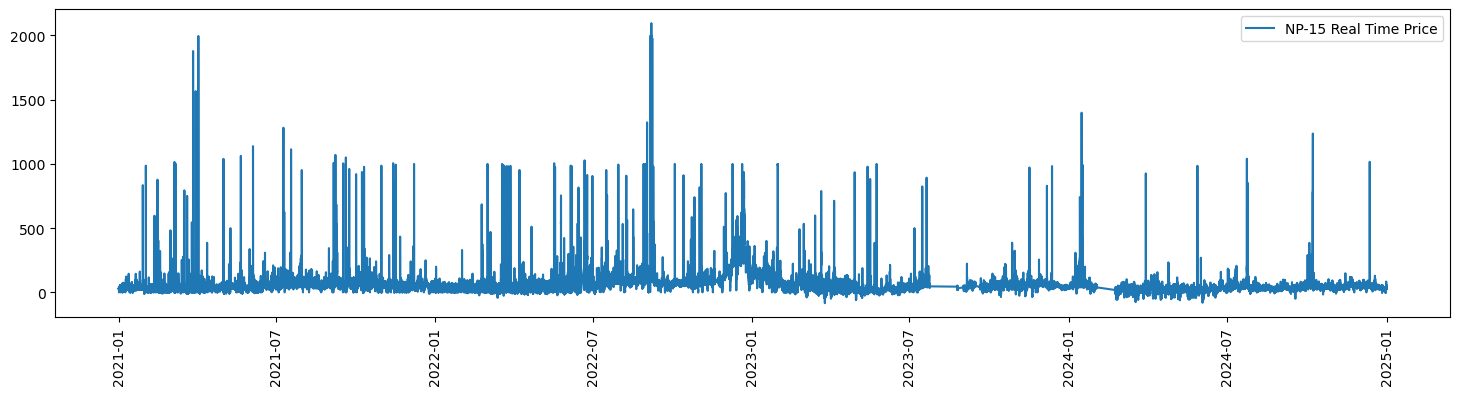

In [19]:
plt.figure(figsize=(18, 4))
plt.plot(data['begin_time'], data['NP-15 LMP'] , label='NP-15 Real Time Price')
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [20]:
print(f'{len(pd.date_range(start=data['begin_time'].min(), end=data['begin_time'].max(), freq='5min'))}')
print(f"{len(data)}")

420768
390751


In [21]:
def process_begin_times(df):
    df['begin_time'] = pd.to_datetime(df['begin_time'])
    df.set_index('begin_time', inplace=True)
    df = df.groupby(df.index).mean()
    dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='5min')
    df = df.reindex(dates)
    df.reset_index(inplace=True)
    df.rename(columns={'index':'begin_time'}, inplace=True)
    return df 

In [22]:
data= process_begin_times(data)
data

,begin_time,NP-15 LMP
0,2021-01-01 00:00:00,30.76070
1,2021-01-01 00:05:00,33.28136
2,2021-01-01 00:10:00,33.98668
3,2021-01-01 00:15:00,31.35044
4,2021-01-01 00:20:00,32.65816
...,...,...
420763,2024-12-31 23:35:00,45.51538
420764,2024-12-31 23:40:00,45.51538
420765,2024-12-31 23:45:00,46.04096
420766,2024-12-31 23:50:00,46.04096


In [23]:
# Get data between specified dates
def filter_times(df, time1, time2):
    return df.apply(lambda x: (time1 <= x['begin_time']) and (x['begin_time'] <= time2) , axis=1)

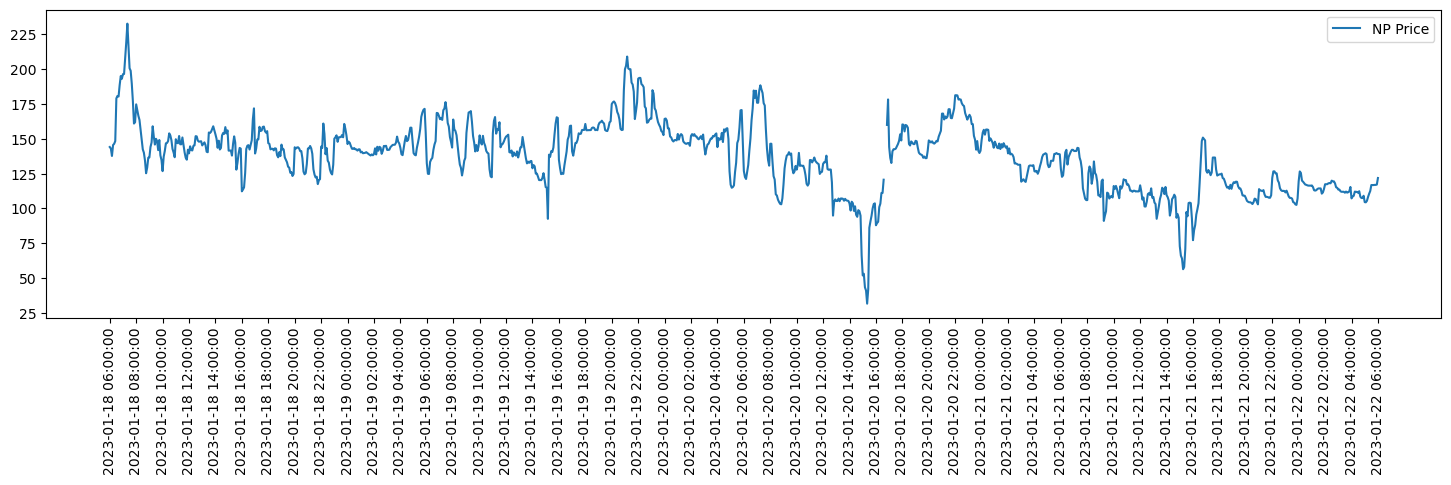

In [25]:
time1 = datetime.datetime(2023, 1, 18, 6, 0, 0)
time2 = datetime.datetime(2023, 1, 22, 6, 0, 0)

filtered_data = data[filter_times(data, time1, time2)]

plt.figure(figsize=(18, 4))
plt.plot(filtered_data['begin_time'], filtered_data['NP-15 LMP'] , label='NP Price')


plt.xticks(ticks=pd.date_range(start=time1, end=time2, freq='2h'), labels=pd.date_range(start=time1, end=time2, freq='2h'), rotation=90)
plt.legend()
plt.show()

In [27]:
result = adfuller(data['NP-15 LMP'].iloc[150000:200000].dropna(), autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values:')
for key, value in result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: -18.241711091260242
p-value: 2.3540978374863817e-30
Critical Values:
   1%: -3.430503857074749
   5%: -2.8616080014029874
   10%: -2.566806194943803


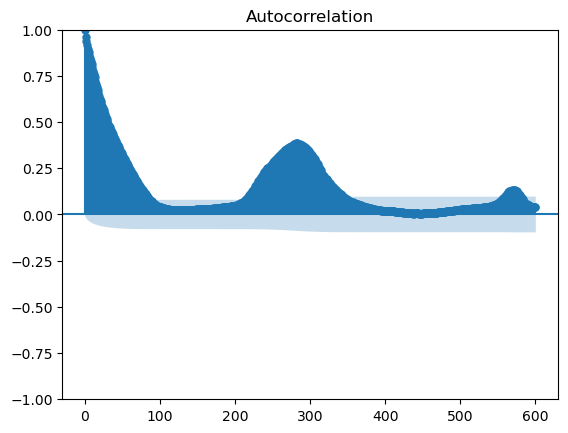

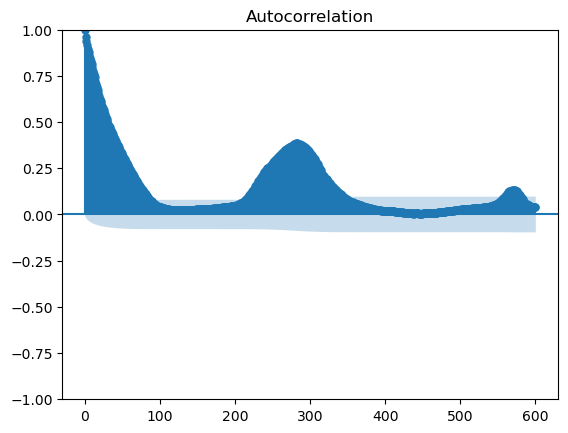

In [31]:
statsmodels.graphics.tsaplots.plot_acf(data['NP-15 LMP'].iloc[150000:180000].dropna(), lags=600)

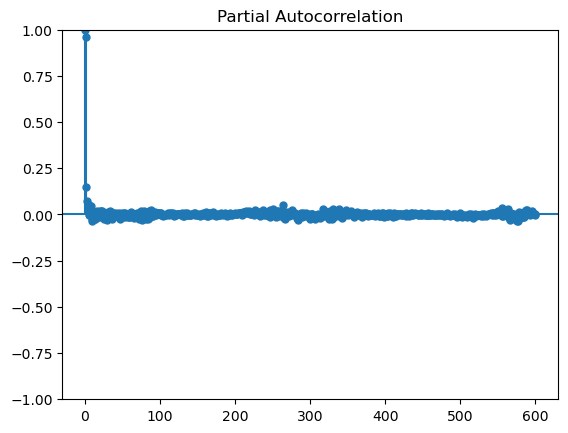

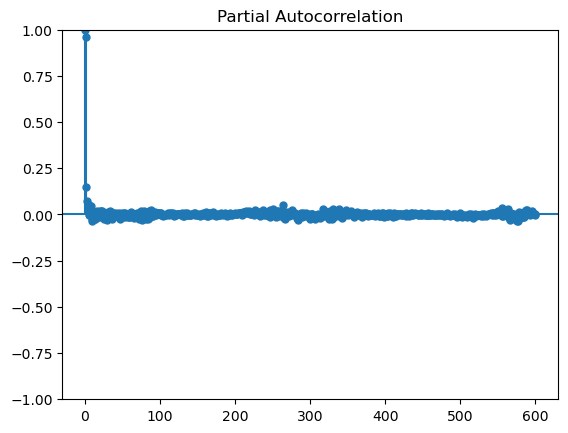

In [36]:
statsmodels.graphics.tsaplots.plot_pacf(data['NP-15 LMP'].iloc[150000:180000].dropna(), lags=600)

In [38]:
data['NP-15 LMP 24hrdiffs'] = data['NP-15 LMP'] - data['NP-15 LMP'].shift(24*12)

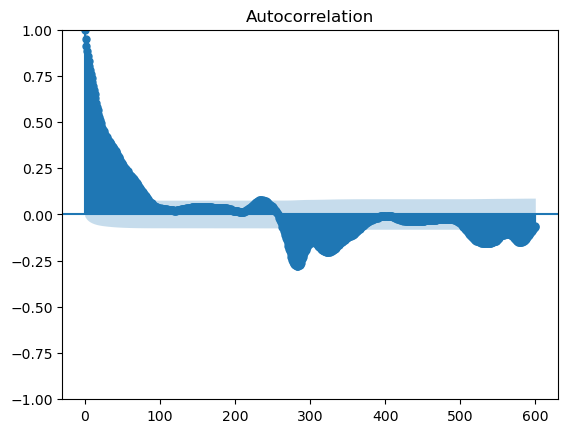

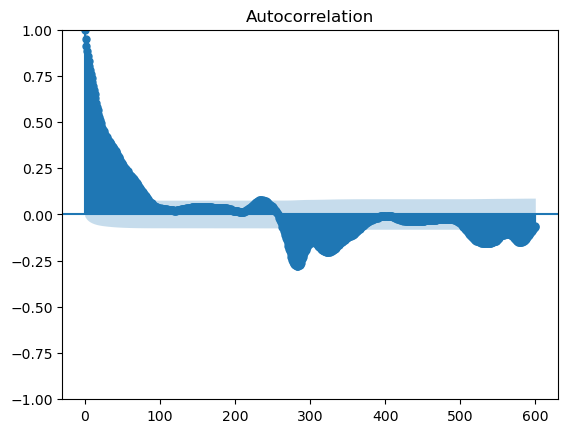

In [46]:
statsmodels.graphics.tsaplots.plot_acf(data['NP-15 LMP 24hrdiffs'].iloc[150000:180000].dropna(), lags=600)

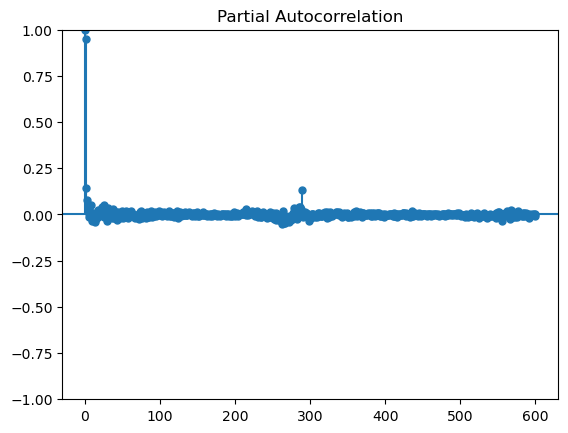

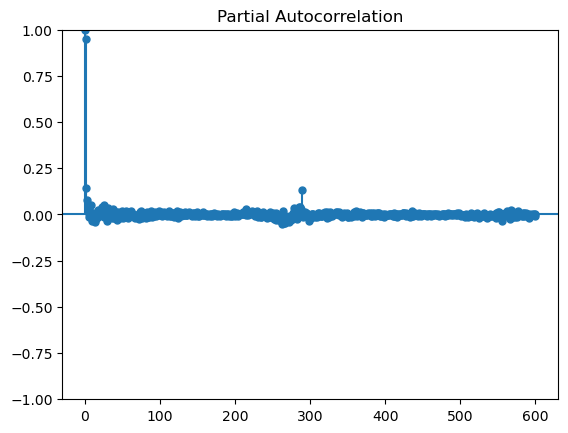

In [47]:
statsmodels.graphics.tsaplots.plot_pacf(data['NP-15 LMP 24hrdiffs'].iloc[150000:180000].dropna(), lags=600)

In [48]:
data.to_csv('Data/preprocessed/NP15_rt_series.csv', index=False)